# Phase 4 - Unsupervised Clustering & Graph Construction

## Independent Loading

In [1]:
import scanpy as sc
import warnings
warnings.filterwarnings('ignore')

print("🚀 INITIALIZING PHASE 4: NETWORK CONSTRUCTION & ECOSYSTEM CLUSTERING")

# Load the exact state from Phase 3 instantaneously
adata = sc.read_h5ad("data/processed/als_spinal_cord_phase3_pca.h5ad")

print(f"Workspace Restored. Current Data Shape: {adata.shape[0]} cells x {adata.shape[1]} genes.")
print(f"Available computed dimensions: {list(adata.obsm.keys())}")

🚀 INITIALIZING PHASE 4: NETWORK CONSTRUCTION & ECOSYSTEM CLUSTERING
Workspace Restored. Current Data Shape: 11371 cells x 19081 genes.
Available computed dimensions: ['X_pca']


## Graph, Communities, & UMAP

In [2]:
#!pip install leidenalg

--- RUNNING PHASE 4 PIPELINE ---
✅ Cellular connectivity graph constructed in: adata.obsp['connectivities']
✅ Unsupervised communities detected in: adata.obs['leiden']
Total distinct clusters identified: 13
✅ 2D UMAP coordinates generated in: adata.obsm['X_umap']


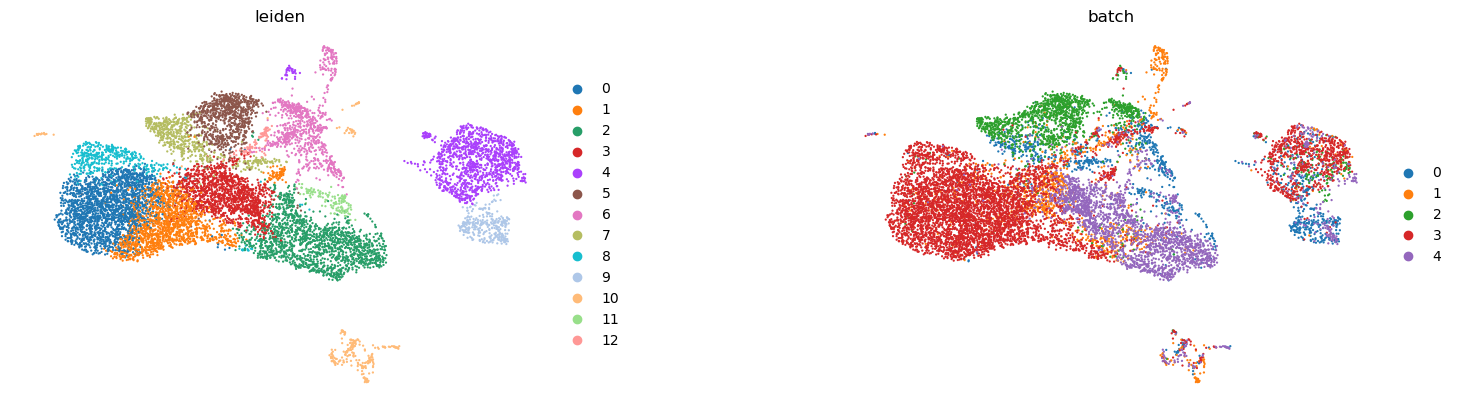

In [3]:
import scanpy as sc
import matplotlib.pyplot as plt

print("--- RUNNING PHASE 4 PIPELINE ---")

# 1. Graph Construction (k-NN Network)
# We use 30 PCs to capture detailed biology, and 15 neighbors to balance local vs global structure
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
print(f"✅ Cellular connectivity graph constructed in: adata.obsp['connectivities']")

# 2. Community Detection (Leiden Clustering)
# Resolution controls cluster granularity. 0.5 is a standard start for ~11k cells
sc.tl.leiden(adata, resolution=0.5)
print(f"✅ Unsupervised communities detected in: adata.obs['leiden']")
print(f"Total distinct clusters identified: {adata.obs['leiden'].nunique()}")

# 3. UMAP Embedding Projection
# Compresses the graph spaces into a scannable 2D coordinate system
sc.tl.umap(adata)
print(f"✅ 2D UMAP coordinates generated in: adata.obsm['X_umap']")

# 4. Visualization
# Let's plot our clusters alongside our technical batches to check for artificial grouping
sc.pl.umap(
    adata, 
    color=['leiden', 'batch'], 
    wspace=0.4, 
    frameon=False,
    show=True
)

#  Phase 5. Differential Expression & Biological Insight

##  MATRIX LOGARITHMIZATION & PLOTTING

--- CORRECTING PHASE 5: MATRIX LOGARITHMIZATION & PLOTTING ---


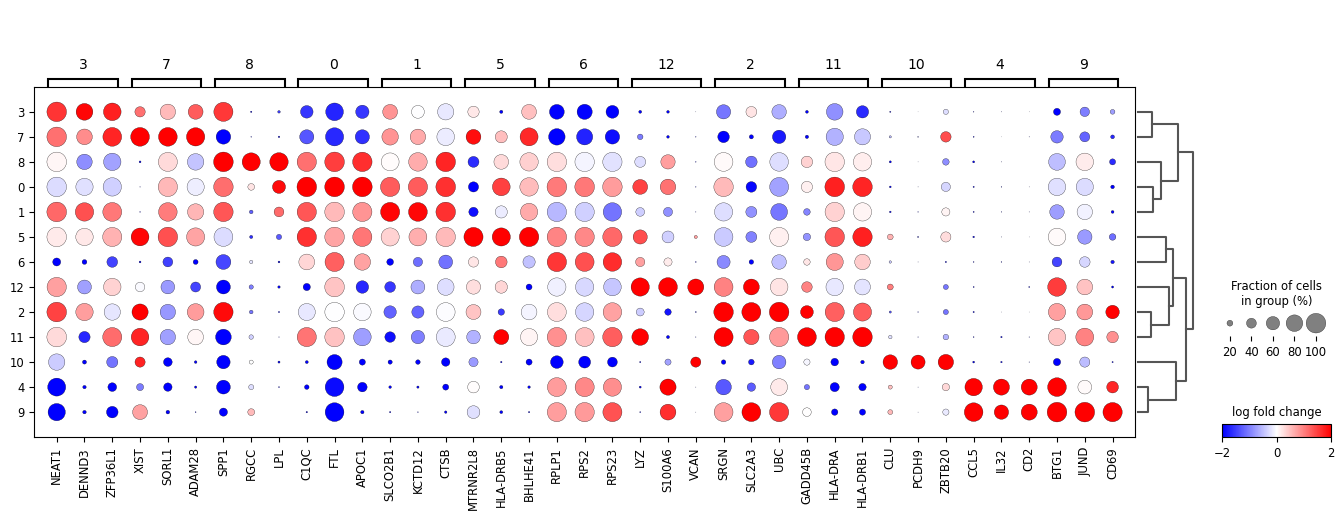

In [4]:
import scanpy as sc
import pandas as pd

print("--- CORRECTING PHASE 5: MATRIX LOGARITHMIZATION & PLOTTING ---")

# 1. Regenerate a clean log-normalized matrix from .raw to clear the raw data warning
adata_de = adata.raw.to_adata()
sc.pp.normalize_total(adata_de, target_sum=1e4)
sc.pp.log1p(adata_de)

# 2. Re-run Wilcoxon rank-sum test on the proper log-normalized counts
sc.tl.rank_genes_groups(
    adata_de, 
    groupby='leiden', 
    method='wilcoxon', 
    corr_method='benjamini-hochberg',
    key_added='wilcoxon_global'
)

# 3. Generate DotPlot (Removing the problematic 'frameon' keyword parameter)
sc.pl.rank_genes_groups_dotplot(
    adata_de,
    key='wilcoxon_global',
    n_genes=3,
    values_to_plot='logfoldchanges',
    cmap='bwr',
    vmin=-2,
    vmax=2
)

In [16]:
#2. See exactly how the clusters mapped to the cell types:
#This grid has exactly 130 empty boxes ($13 \times 10 = 130$).
print(adata.obs.groupby(['leiden', 'cell_type'], observed=True).size())

leiden  cell_type                         
0       Homeostatic Microglia                 2131
1       Homeostatic Microglia                 1617
2       Pre-inflammatory Microglia            1603
3       Stress-Response Microglia             1376
4       Infiltrating T-Cells                  1194
5       Homeostatic Microglia                  847
6       Erythrocyte Contamination              791
7       XIST+ Microglia Subset                 579
8       Disease-Associated Microglia (DAM)     420
9       Infiltrating T-Cells                   315
10      Synaptic Debris/Astrocytes             272
11      Activated Microglia                    128
12      Infiltrating Monocytes                  98
dtype: int64


# Phase 6: Downstream Advanced Analytics & Compositional Modeling

## Step 1: Programmatic Cell-Type Annotation

In [5]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INITIALIZING PHASE 6: CELL-TYPE ANNOTATION ---")

# 1. Define the explicit biological dictionary based on Phase 5 marker profiles
cluster_annotations = {
    '0': 'Homeostatic Microglia',
    '1': 'Homeostatic Microglia',
    '2': 'Pre-inflammatory Microglia',
    '3': 'Stress-Response Microglia',
    '4': 'Infiltrating T-Cells',
    '5': 'Homeostatic Microglia',
    '6': 'Erythrocyte Contamination',
    '7': 'XIST+ Microglia Subset',
    '8': 'Disease-Associated Microglia (DAM)',
    '9': 'Infiltrating T-Cells',
    '10': 'Synaptic Debris/Astrocytes',
    '11': 'Activated Microglia',
    '12': 'Infiltrating Monocytes'
}

# 2. Map the dictionary into a new categorical column inside cell metadata (.obs)
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotations)

# Verify the cell type distributions
print("\nCell counts per annotated population:")
print(adata.obs['cell_type'].value_counts())

--- INITIALIZING PHASE 6: CELL-TYPE ANNOTATION ---

Cell counts per annotated population:
cell_type
Homeostatic Microglia                 4595
Pre-inflammatory Microglia            1603
Infiltrating T-Cells                  1509
Stress-Response Microglia             1376
Erythrocyte Contamination              791
XIST+ Microglia Subset                 579
Disease-Associated Microglia (DAM)     420
Synaptic Debris/Astrocytes             272
Activated Microglia                    128
Infiltrating Monocytes                  98
Name: count, dtype: int64


## Step 2: Compositional Tracking Across Donors


--- COMPOSITIONAL PERCENTAGE MATRIX CONTENT ---


cell_type,Activated Microglia,Disease-Associated Microglia (DAM),Erythrocyte Contamination,Homeostatic Microglia,Infiltrating Monocytes,Infiltrating T-Cells,Pre-inflammatory Microglia,Stress-Response Microglia,Synaptic Debris/Astrocytes,XIST+ Microglia Subset
donor_id,,,,,,,,,,
ALS1,0.17,1.17,17.01,18.85,1.75,4.50,16.26,32.53,6.67,1.08
ALS2,0.00,0.47,13.69,51.19,0.47,10.58,2.31,0.95,0.14,20.20
ALS3,0.06,7.22,1.93,66.56,0.58,13.00,2.36,7.01,1.22,0.06
ALS4,7.02,0.75,17.96,3.34,2.92,34.92,5.26,1.59,4.34,21.89
ALS5,1.80,0.23,3.09,1.15,0.18,8.67,54.66,26.71,3.37,0.14


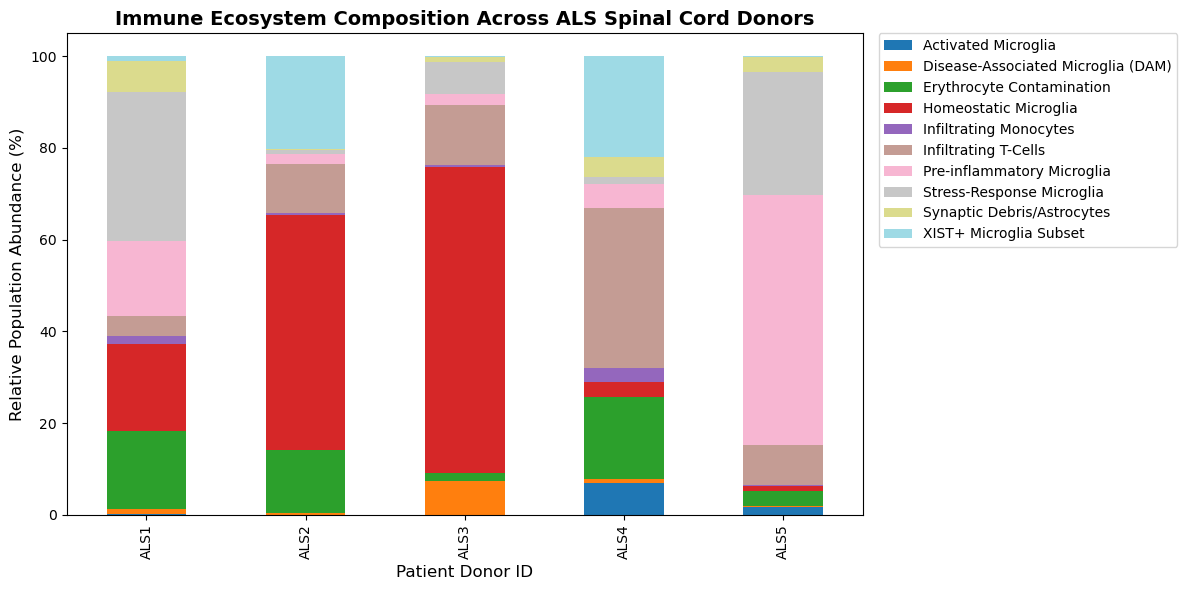

In [6]:
# 1. Build a contingency table of counts (Donor ID vs Cell Type)
count_table = pd.crosstab(adata.obs['donor_id'], adata.obs['cell_type'])

# 2. Convert raw counts into relative percentages per donor (rows sum to 100%)
percentage_table = count_table.div(count_table.sum(axis=1), axis=0) * 100

print("\n--- COMPOSITIONAL PERCENTAGE MATRIX CONTENT ---")
display(percentage_table.round(2))

# 3. Plot a publication-quality Stacked Bar Plot
ax = percentage_table.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    colormap='tab20'
)

plt.title('Immune Ecosystem Composition Across ALS Spinal Cord Donors', fontsize=14, weight='bold')
plt.xlabel('Patient Donor ID', fontsize=12)
plt.ylabel('Relative Population Abundance (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

## Step 3: Quantifying Clinical Stratification

In [7]:
# Isolate the DAM population column and rank the donors descending
dam_burden = percentage_table['Disease-Associated Microglia (DAM)'].sort_values(ascending=False)

print("\n===========================================================================")
print("📊 CLINICAL STRATIFICATION: PATIENT RANKING BY DAM BURDEN (%)")
print("===========================================================================")
print(dam_burden.round(2).apply(lambda x: f"{x}%"))


📊 CLINICAL STRATIFICATION: PATIENT RANKING BY DAM BURDEN (%)
donor_id
ALS3    7.22%
ALS1    1.17%
ALS4    0.75%
ALS2    0.47%
ALS5    0.23%
Name: Disease-Associated Microglia (DAM), dtype: object


# Dashboard Data Extraction Layer

In [9]:
import pandas as pd

print("📦 Extracting optimized dataframe for interactive dashboard web app...")

# 1. Initialize dataframe with coordinates from your manifold projection
dash_df = pd.DataFrame(
    adata.obsm["X_umap"], columns=["UMAP_1", "UMAP_2"], index=adata.obs_names
)

# 2. Append categorical biological annotations and donor clinical tracking data
dash_df["Cell_Type"] = adata.obs["cell_type"].astype(str)
dash_df["Donor_ID"] = adata.obs["donor_id"].astype(str)

# 3. Pull the specific gene vectors used in your Phase 5 Validation DotPlot
# This lets the PI query the key genes driving the ALS immune ecosystem on the fly
target_markers = [
    "NEAT1",
    "XIST",
    "SORL1",
    "SPP1",
    "RGCC",
    "LPL",
    "C1QC",
    "FTL",
    "CD3E",
    "CCL5",
    "CD2",
    "HBB",
    "GFAP",
]

for gene in target_markers:
    if gene in adata.var_names:
        # Flatten the sparse matrix array into a standard 1D list column
        dash_df[gene] = adata[:, gene].X.toarray().flatten()

# 4. Save as a highly performant, lightweight file (Only ~3-5 MB instead of 1.8 GB!)
dash_df.to_csv("data/processed/dashboard_data.csv")
print("🎉 Production dashboard layer successfully generated and compressed!")

📦 Extracting optimized dataframe for interactive dashboard web app...
🎉 Production dashboard layer successfully generated and compressed!
